# Causal Inference Beyond A/B Testing
## Propensity-score matching and synthetic control

**Contributors:** Jonathan Sauer, Muhammad Murodzoda, Sebastian Aguilar  
**Portfolio presentation:** Muhammad Murodzoda

Two observational case studies explore how to construct counterfactual comparisons when randomized experiments are unavailable:

1. **UN interventions and conflict duration:** propensity scores, caliper matching, overlap, covariate balance, and post-matching estimation.
2. **German reunification and GDP per capita:** donor weighting, constrained synthetic control, and placebo diagnostics.

This portfolio edition rewrites the narrative of a collaborative university analysis. **Every original code cell, code comment, saved output, warning, execution count, and cell metadata entry is preserved. No code was executed for this revision.** Interpretation notes distinguish the implemented methods from their assumptions and limitations.

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import duckdb as ddb
# Load dataset
data = pd.read_stata("data/war_pre_snapshots.dta")
# add an unique identifier
data["id"] = np.arange(len(data))

## Case study 1 — UN interventions and conflict duration

### Research question

How does observed conflict duration differ between UN-intervention snapshots and comparable untreated snapshots? Intervention is not randomly assigned: conflict severity, strategic considerations, and institutional conditions can influence both intervention and subsequent outcomes.

The supplied data are associated with Gilligan and Sergenti (2008), *Do UN Interventions Cause Peace? Using Matching to Improve Causal Inference*. Matching addresses differences in **observed pre-treatment covariates**; it cannot by itself remove unobserved confounding.

### Data and estimand

`data/war_pre_snapshots.dta` contains **1,227 rows**, including **16 treated** and **1,211 untreated** observations. The source has 69 distinct in-war period IDs across 49 countries, so these are not 1,227 independent wars. The first code cell replaces the supplied ID with a row identifier.

The code uses `UN` as treatment and **`dur`** as outcome. In the supplied file, `dur = t - t0`, and every value matches the calendar-month difference between `date0` and `date1`. Duration results are therefore described here in **months**, despite the original charts' retained “days” labels. The file includes an event indicator `_d`; the matching analysis does not model censoring.

The propensity models use 14 fields: `inter`, `deaths`, `couprev`, `sos`, `drugs`, `t0`, `ethfrac`, `pop`, `lmtnest`, `milper`, `eeurop`, `lamerica`, `asia`, and `ssafrica`. Source transformations and timing should be checked against the original documentation; `t0` is an analysis-time field, not a calendar start year, and `deaths` is not assumed to be a raw count.

The intended estimand is an ATT-style comparison for the **treated snapshots that find acceptable controls**. Discarding treated observations changes the target population. Identification additionally requires a defensible outcome definition, consistent treatment, conditional exchangeability, and suitable untreated support for the treated covariate profiles.

### Data inspection and treatment assignment

The following diagnostics summarize the sample, missingness, treatment prevalence, and associations between covariates and intervention. Treatment-prediction coefficients and p-values describe assignment patterns; they do not establish which variables are causally valid adjustment variables.

=== Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        1227 non-null   int64         
 1   cname     1227 non-null   object        
 2   ccode     1227 non-null   float64       
 3   date0     1227 non-null   datetime64[ns]
 4   date1     1227 non-null   datetime64[ns]
 5   UN        1227 non-null   float32       
 6   inter     1227 non-null   float32       
 7   deaths    1227 non-null   float32       
 8   couprev   1227 non-null   float32       
 9   sos       1227 non-null   float32       
 10  drugs     1227 non-null   float32       
 11  ethfrac   1227 non-null   float32       
 12  pop       1227 non-null   float32       
 13  lmtnest   1227 non-null   float32       
 14  milper    1227 non-null   float32       
 15  eeurop    1227 non-null   float32       
 16  lamerica  1227 non-null   float32  

,id,cname,ccode,date0,date1,UN,inter,deaths,couprev,sos,...,lamerica,asia,ssafrica,nafrme,t0,_st,t,_d,dur,ldur
0,0,Haiti,41.0,1991-01-01,1991-12-01,0.0,0.0,5.521461,1.0,0.0,...,1.0,0.0,0.0,0.0,0,1,11,1,11.0,2.397895
1,1,Guatemala,90.0,1988-01-01,1995-12-01,0.0,0.0,6.214608,0.0,0.0,...,1.0,0.0,0.0,0.0,255,1,350,1,95.0,4.553877
2,2,El Salvador,92.0,1991-07-01,1991-12-01,1.0,0.0,5.010635,0.0,0.0,...,1.0,0.0,0.0,0.0,150,1,155,1,5.0,1.609438
3,3,Nicaragua,93.0,1988-01-01,1989-12-01,0.0,0.0,8.006368,0.0,0.0,...,1.0,0.0,0.0,0.0,73,1,96,1,23.0,3.135494
4,4,Colombia,100.0,1988-01-01,2003-12-01,0.0,0.0,6.570883,0.0,0.0,...,1.0,0.0,0.0,0.0,276,1,467,0,191.0,5.252274



=== Summary Statistics (Numerical Variables) ===


,count,mean,min,25%,50%,75%,max,std
id,1227.0,613.0,0.0,306.5,613.0,919.5,1226.0,354.348698
ccode,1227.0,558.823146,41.0,483.0,541.0,770.0,910.0,219.301142
date0,1227,1991-12-05 15:01:19.217603968,1988-01-01 00:00:00,1988-01-01 00:00:00,1990-06-01 00:00:00,1995-11-01 00:00:00,2002-10-01 00:00:00,NaN
date1,1227,1997-06-22 02:50:10.268948608,1988-12-01 00:00:00,1992-10-01 00:00:00,1996-12-01 00:00:00,2003-12-01 00:00:00,2003-12-01 00:00:00,NaN
UN,1227.0,0.01304,0.0,0.0,0.0,0.0,1.0,0.113492
inter,1227.0,0.105134,0.0,0.0,0.0,0.0,1.0,0.306852
deaths,1227.0,6.617658,0.0,5.298317,6.570883,7.708859,10.779644,1.95646
couprev,1227.0,0.0489,0.0,0.0,0.0,0.0,1.0,0.215746
sos,1227.0,0.409943,0.0,0.0,0.0,1.0,1.0,0.492023
drugs,1227.0,0.268134,0.0,0.0,0.0,1.0,1.0,0.443168



=== Missing Values ===


id          0
cname       0
ccode       0
date0       0
date1       0
UN          0
inter       0
deaths      0
couprev     0
sos         0
drugs       0
ethfrac     0
pop         0
lmtnest     0
milper      0
eeurop      0
lamerica    0
asia        0
ssafrica    0
nafrme      0
t0          0
_st         0
t           0
_d          0
dur         0
ldur        0
dtype: int64


=== Value Counts for Categorical Variables ===

UN:
UN
0.0    1211
1.0      16
Name: count, dtype: int64

inter:
inter
0.0    1098
1.0     129
Name: count, dtype: int64

couprev:
couprev
0.0    1167
1.0      60
Name: count, dtype: int64

sos:
sos
0.0    724
1.0    503
Name: count, dtype: int64

drugs:
drugs
0.0    898
1.0    329
Name: count, dtype: int64

eeurop:
eeurop
0.0    1152
1.0      75
Name: count, dtype: int64

lamerica:
lamerica
0.0    1091
1.0     136
Name: count, dtype: int64

asia:
asia
0.0    844
1.0    383
Name: count, dtype: int64

ssafrica:
ssafrica
0.0    743
1.0    484
Name: count, dtype: int64


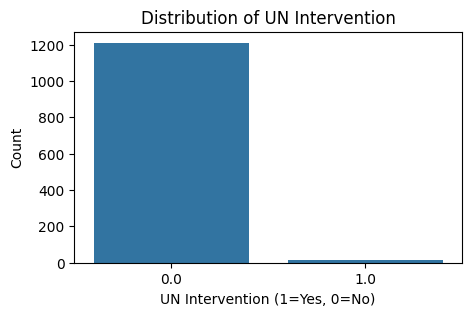

Top predictors of UN intervention:
    Variable  Coefficient  Odds_Ratio   P_Value
11  lamerica    -3.774950    0.022938  0.029182
4      drugs     3.237644   25.473637  0.002897
12      asia    -2.439652    0.087191  0.134568
10    eeurop     2.185903    8.898684  0.140916
13  ssafrica    -1.336797    0.262686  0.379578
9     milper    -1.123162    0.325250  0.001375
3        sos    -1.075416    0.341156  0.279144
0      inter     0.928601    2.530967  0.272635
8    lmtnest     0.271093    1.311397  0.398588
7        pop    -0.270575    0.762941  0.565457
1     deaths    -0.155546    0.855948  0.475418
2    couprev    -0.113086    0.893073  0.926960
6    ethfrac    -0.016283    0.983849  0.349657
5         t0     0.005487    1.005502  0.113438


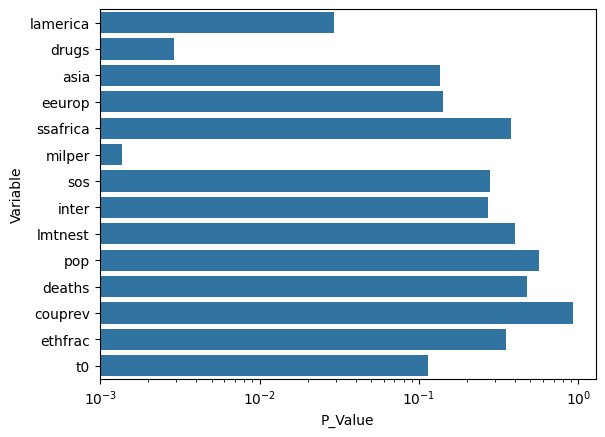

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Basic info
print("=== Dataset Overview ===")
print(data.info())
print("\n=== First 5 Rows ===")
display(data.head())

# Quick summary statistics
print("\n=== Summary Statistics (Numerical Variables) ===")
display(data.describe().T)

# Check for missing values
print("\n=== Missing Values ===")
display(data.isna().sum().sort_values(ascending=False))

# Value counts for categorical / binary variables
categorical_vars = ["UN", "inter", "couprev", "sos", "drugs", "eeurop", "lamerica", "asia", "ssafrica"]
print("\n=== Value Counts for Categorical Variables ===")
for var in categorical_vars:
    print(f"\n{var}:")
    print(data[var].value_counts(dropna=False))

# Quick visualization: treatment distribution
plt.figure(figsize=(5,3))
sns.countplot(x="UN", data=data)
plt.title("Distribution of UN Intervention")
plt.xlabel("UN Intervention (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

# Build a simple logistic model to predict war onset
covariates = ["inter", "deaths", "couprev", "sos", "drugs", "t0",
  "ethfrac", "pop", "lmtnest", "milper",
  "eeurop", "lamerica", "asia", "ssafrica"]  
target = "dur"
treatment = "UN"
X = data[covariates]
y = data[treatment]
# model
model = LogisticRegression(solver='liblinear', random_state=0)
res = model.fit(X, y)
y_pred = model.predict(X)
ps_logit = model.predict_proba(X)[:, 1]
# Use statsmodels to obtain standard errors and p-values
X_sm = sm.add_constant(X)
logit_sm = sm.Logit(y, X_sm).fit(disp=False)
coef = logit_sm.params.drop('const')
p_values = logit_sm.pvalues.drop('const')
odds_ratio = np.exp(coef)

# Create results dataframe
coef_df = pd.DataFrame({
    'Variable': coef.index,
    'Coefficient': coef.values,
    'Odds_Ratio': odds_ratio.values,
    'P_Value': p_values.values
})

# Sort by absolute coefficient value
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print("Top predictors of UN intervention:")
print(coef_df[['Variable', 'Coefficient', 'Odds_Ratio', 'P_Value']].head(20))
# print as barplot
g = sns.barplot(data=coef_df, x='P_Value', y='Variable')
g.set_xscale("log")


### 1. Estimating propensity scores

The propensity score is $e(X_i)=P(T_i=1\mid X_i)$. Two model families are explored: logistic regression and a random forest.

**Implementation note:** the next cell calculates statsmodels logit predictions, but later overwrites `data['ps_logit']` with `ps_logit` from the earlier scikit-learn logistic model. The subsequent matching results therefore use that earlier model's probabilities. Both prediction models are evaluated on their training data; the random forest's perfect classification score is not out-of-sample performance or evidence of a better causal design.

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1211
         1.0       1.00      1.00      1.00        16

    accuracy                           1.00      1227
   macro avg       1.00      1.00      1.00      1227
weighted avg       1.00      1.00      1.00      1227

milper      0.204514
lmtnest     0.167057
pop         0.161738
deaths      0.138484
ethfrac     0.101755
t0          0.091721
eeurop      0.035818
inter       0.028689
sos         0.020028
drugs       0.019708
ssafrica    0.017964
asia        0.005356
lamerica    0.004368
couprev     0.002800
dtype: float64


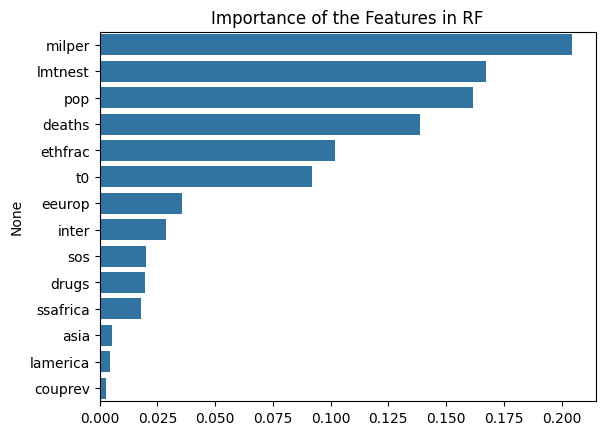


Group: UN = 0
Logistic Regression PS:
Mean: 0.012
Std:  0.021
Range: [0.000, 0.151]

Random Forest PS:
Mean: 0.001
Std:  0.005
Range: [0.000, 0.100]

Group: UN = 1
Logistic Regression PS:
Mean: 0.119
Std:  0.145
Range: [0.001, 0.577]

Random Forest PS:
Mean: 0.731
Std:  0.055
Range: [0.610, 0.830]


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report
import statsmodels.api as sm

# Prepare data
covariates = ["inter", "deaths", "couprev", "sos", "drugs", "t0",
              "ethfrac", "pop", "lmtnest", "milper",
              "eeurop", "lamerica", "asia", "ssafrica"]
X = data[covariates]
y = data["UN"]

# 1. Logistic Regression propensity scores
X_logit = sm.add_constant(X, has_constant='add')

# Fit logistic regression: T_i ~ X_i
logit_model = sm.Logit(y, X_logit)
logit_result = logit_model.fit(disp=False)

# Estimated propensity scores
data['ps_logit'] = logit_result.predict(X_logit)

# 2. Random Forest propensity scores
rf = RandomForestClassifier(n_estimators=100, random_state=0)
fitted_rf = rf.fit(X, y)
ps_rf = rf.predict_proba(X)[:, 1]
print(classification_report(y, rf.predict(X)))
importances = pd.Series(rf.feature_importances_, index=covariates).sort_values(ascending=False)
print(importances)
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importance of the Features in RF")
plt.show()



# Add propensity scores to dataset
data['ps_logit'] = ps_logit
data['ps_rf'] = ps_rf

# Summary statistics for treated (UN=1) and control (UN=0) groups
for group in [0, 1]:
    mask = data['UN'] == group
    print(f"\nGroup: UN = {group}")
    print("Logistic Regression PS:")
    print(f"Mean: {ps_logit[mask].mean():.3f}")
    print(f"Std:  {ps_logit[mask].std():.3f}")
    print(f"Range: [{ps_logit[mask].min():.3f}, {ps_logit[mask].max():.3f}]")
    print("\nRandom Forest PS:")
    print(f"Mean: {ps_rf[mask].mean():.3f}")
    print(f"Std:  {ps_rf[mask].std():.3f}")
    print(f"Range: [{ps_rf[mask].min():.3f}, {ps_rf[mask].max():.3f}]")

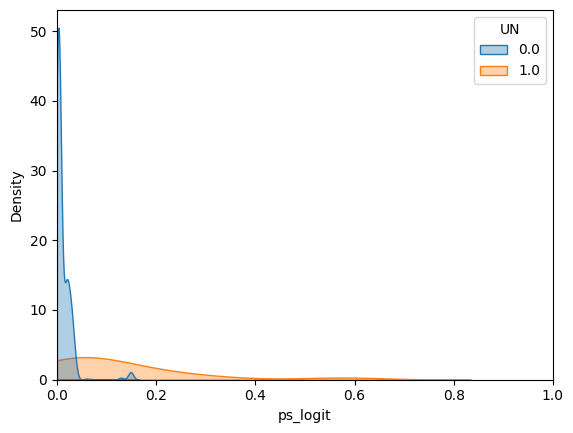

In [30]:
sns.kdeplot(data=data, x='ps_logit', hue='UN', fill=True, common_norm=False, clip=(0, 1), alpha=0.35)
plt.xlim(0, 1)
plt.show()


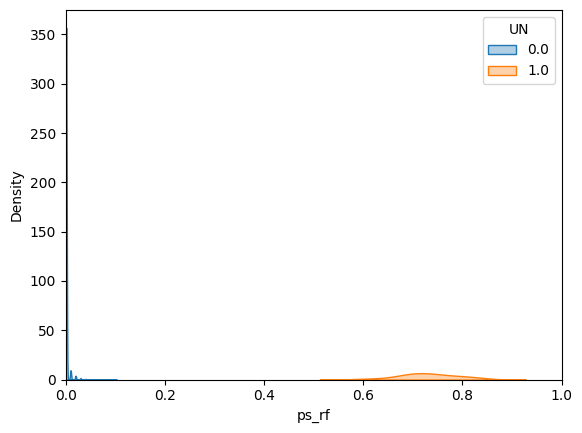

In [31]:
ps_rf_plot = data['ps_rf'].clip(1e-3, 1 - 1e-3)
sns.kdeplot(x=ps_rf_plot, hue=data['UN'], fill=True, common_norm=False, clip=(0, 1), alpha=0.35)
plt.xlim(0, 1)
plt.show()


In [32]:
# summary stats
def ps_summary(data, ps_col):
    summary = data.groupby('UN')[ps_col].agg(['mean','std','min','max']).rename(index={0:'Control',1:'Treated'})
    return summary

summary_stats = ps_summary(data, 'ps_logit')
print(summary_stats)

summary_stats = ps_summary(data, 'ps_rf')
print(summary_stats)

             mean       std       min       max
UN                                             
Control  0.011690  0.020550  0.000224  0.150716
Treated  0.118689  0.149254  0.000923  0.576755
             mean       std   min   max
UN                                     
Control  0.000743  0.004575  0.00  0.10
Treated  0.730625  0.056741  0.61  0.83


### Propensity-score distributions

The saved logistic scores range from about **0.000224–0.150716** in controls and **0.000923–0.576755** in treated observations. Random-forest scores range from **0–0.10** in controls and **0.61–0.83** in treated observations, leaving no shared score range in this fitted model.

This contrast illustrates why treatment prediction and causal comparison are different objectives. The fitted forest separates the groups but supplies no comparable controls under the implemented matching rule. It does not prove that population-level overlap is absent or that forests always perform poorly for propensity estimation.

In [33]:
data["ps_logit"]

0       0.024327
1       0.005824
2       0.006290
3       0.017390
4       0.023720
          ...   
1222    0.001750
1223    0.006123
1224    0.001599
1225    0.000878
1226    0.000330
Name: ps_logit, Length: 1227, dtype: float64

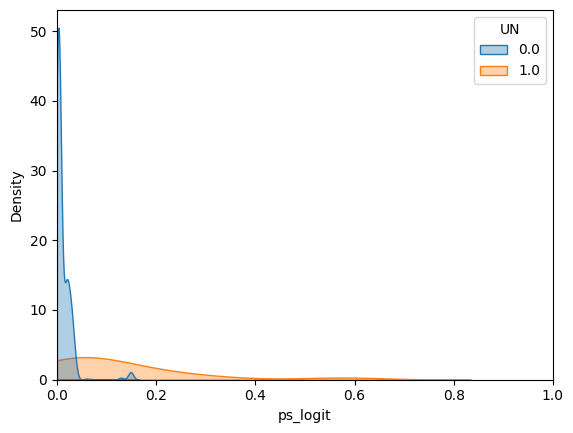

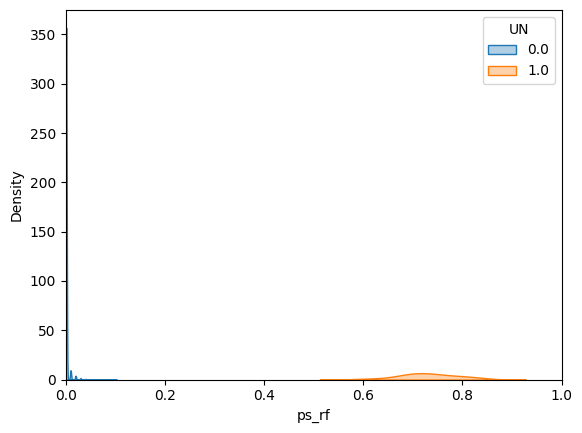

In [34]:
# create kde plot
sns.kdeplot(data=data, x='ps_logit', hue='UN', fill=True, common_norm=False, clip=(0, 1), alpha=0.35)
plt.xlim(0, 1)
plt.show()

ps_rf_plot = data['ps_rf'].clip(1e-3, 1 - 1e-3)
sns.kdeplot(x=ps_rf_plot, hue=data['UN'], fill=True, common_norm=False, clip=(0, 1), alpha=0.35)
plt.xlim(0, 1)
plt.show()


### 2. Designing the matched comparison

The matching procedure searches for nearby untreated observations and allows a control to be used by more than one treated observation. A caliper limits acceptable distances. Matching choices are assessed using retained sample size, overlap, and covariate balance.

#### Distance scales and calipers

The logistic-score implementation matches on

$$\ell_i=\log\left(\frac{\widehat e(X_i)}{1-\widehat e(X_i)}\right)$$

with a caliper of **0.2 × the sample standard deviation of that logit score**. The random-forest implementation instead matches on **raw predicted probabilities**, with 0.2 × their standard deviation. These designs therefore differ in both fitted scores and matching scale.

The code also plots logit-transformed forest scores. Zero probabilities produce the saved divide-by-zero warning; the original warning and plots are retained.

/home/ich/PycharmProjects/sampling-and-data-course/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


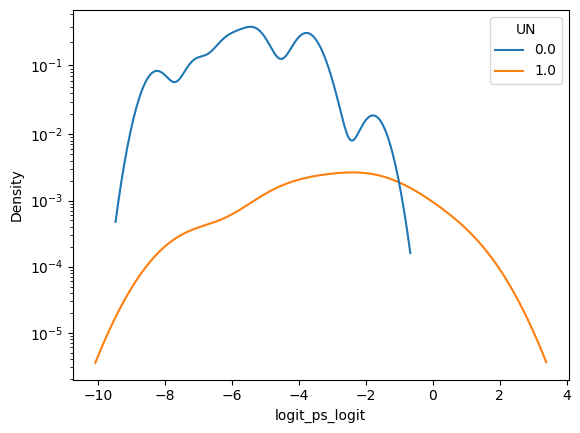

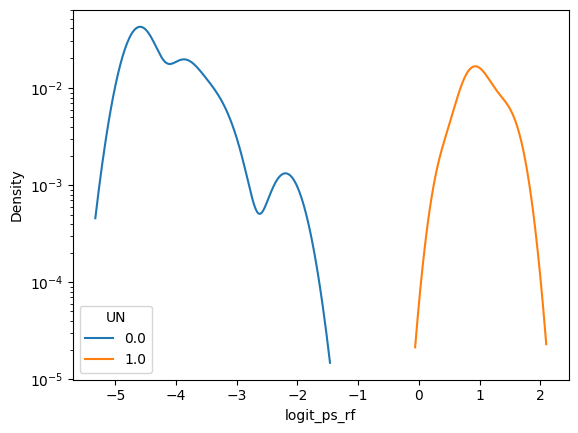

In [35]:
def logit_ps(ps):
    return np.log(ps / (1 - ps))

data['logit_ps_logit'] = logit_ps(data['ps_logit'])
data['logit_ps_rf'] = logit_ps(data['ps_rf'])

sns.kdeplot(data=data, x='logit_ps_logit', hue='UN')
plt.yscale("logit")
plt.show()
sns.kdeplot(data=data, x='logit_ps_rf', hue='UN')
plt.yscale("logit")
plt.show()

#### Nearest-neighbor matching with replacement

The following cells construct matched pairs and attach the original covariates and outcomes for comparison. The output tables identify which observations were selected rather than assuming all treated units have a usable counterfactual.

In [36]:
# Separate treatment and control
control = data[data['UN'] == 0].copy()
treatment = data[data['UN'] == 1].copy()

caliper = 0.2 * data['logit_ps_logit'].std()
matched_pairs = []

for _, tunit in treatment.iterrows():
    min_dist = float('inf')
    best_match_id = None

    for _, cunit in control.iterrows():
        dist = abs(tunit['logit_ps_logit'] - cunit['logit_ps_logit'])
        if dist < min_dist and dist <= caliper:
            min_dist = dist
            best_match_id = cunit['id']          # store the control’s id

    if best_match_id is not None:
        matched_pairs.append({
            'treated_id': tunit['id'],
            'control_id': best_match_id,
            'distance': min_dist
        })

matched_df = pd.DataFrame(matched_pairs)
t_cols = ",\n    ".join([f't."{col}" AS t_{col}' for col in data.columns])
c_cols = ",\n    ".join([f'c."{col}" AS c_{col}' for col in data.columns])

sql = f"""
SELECT
    m.*,
    {t_cols},
    {c_cols}
FROM matched_df m
LEFT JOIN data t ON m.treated_id = t.id
LEFT JOIN data c ON m.control_id = c.id
"""
matched_logit = ddb.query(sql).df()
treated_covariates = [f't_{col}' for col in covariates]
control_covariates = [f'c_{col}' for col in covariates]



In [37]:
# do matching for random forest propensity score
caliper = 0.2 * data['ps_rf'].std()
matched_pairs_rf = []
for _, tunit in treatment.iterrows():
    min_dist = float('inf')
    best_match_id = None

    for _, cunit in control.iterrows():
        dist = abs(tunit['ps_rf'] - cunit['ps_rf'])
        if dist < min_dist and dist <= caliper:
            min_dist = dist
            best_match_id = cunit['id']          # store the control’s id

    if best_match_id is not None:
        matched_pairs_rf.append({
            'treated_id': tunit['id'],
            'control_id': best_match_id,
            'distance': min_dist
        })
matched_df_rf = pd.DataFrame(
    matched_pairs_rf,
    columns=['treated_id', 'control_id', 'distance']
)

# print numbers matched
print(f"Number of matched pairs (RF): {len(matched_df_rf)} out of {len(treatment)}")
if matched_df_rf.empty:
    print('No matched pairs were found with the current caliper.')
    matched_rf = pd.DataFrame()
else:
    matched_rf = ddb.query("""
        SELECT *
        FROM matched_df_rf m
        LEFT JOIN data t ON m.treated_id = t.id
        LEFT JOIN data c ON m.control_id = c.id
    """).df()
matched_rf


Number of matched pairs (RF): 0 out of 16
No matched pairs were found with the current caliper.


""


#### Match retention and target population

The stored logistic match table contains **13 of 16 treated observations**; three do not obtain a valid match. The forest produces **zero matches**, so no forest-based ATT is available.

The logistic estimate pertains to the retained treated snapshots, not automatically to all UN interventions. A caliper can permit a nearby match just outside the controls' observed score range, so 13 matched units need not equal the 12 treated units inside the strict min–max control support reported later.

### 3. Balance and overlap diagnostics

Good matches should bring observed covariate distributions closer together. Score proximity alone does not establish balance, and balance on observed variables does not establish exchangeability on unobserved factors.

#### Standardized mean differences

A common diagnostic compares the treated and control means relative to a scale measure:

$$\operatorname{SMD}(X)=\frac{\bar X_T-\bar X_C}{s_T}.$$

The preserved helper uses the standard deviation of the treated values supplied to it. Consequently, the post-match denominator is recomputed on the matched treated sample; it is **not held fixed at the original treated-sample standard deviation**. Before–after SMD changes reflect both mean differences and possible changes in that denominator.

#### Reading the balance plots

The saved post-match SMDs show substantial remaining imbalance, including approximately **0.74 for `drugs`**, **0.63 for `t0`**, and **0.59 for `inter`**. Matching therefore does not deliver close balance on all measured characteristics. The plots retain the original zero reference line; no 0.1 threshold line was added.

Additional plots examine products and squared terms. One product, `deaths_dur`, includes the outcome itself and should not be interpreted as a pre-treatment covariate-balance diagnostic. Undefined SMDs can occur for constant terms. These observations are interpretation notes only; the original computations are unchanged.

In [38]:
matched_logit

,treated_id,control_id,distance,t_id,t_cname,t_ccode,t_date0,t_date1,t_UN,t_inter,...,c_t0,c__st,c_t,c__d,c_dur,c_ldur,c_ps_logit,c_ps_rf,c_logit_ps_logit,c_logit_ps_rf
0,48,10,0.232046,48,Lebanon,660.0,1988-01-01,1990-12-01,1.0,1.0,...,0,1,4,1,4.0,1.386294,0.128892,0.10,-1.910788,-2.197225
1,39,34,0.059085,39,Angola,540.0,1988-12-01,2002-12-01,1.0,1.0,...,0,1,67,1,67.0,4.204693,0.013848,0.00,-4.265642,-inf
2,6,36,0.057348,6,Croatia,344.0,1992-02-01,1993-12-01,1.0,1.0,...,0,1,37,1,37.0,3.610918,0.059823,0.02,-2.754676,-3.891820
3,13,181,0.007126,13,Georgia,372.0,1993-08-01,1993-12-01,1.0,0.0,...,3,1,4,1,1.0,0.000000,0.129423,0.02,-1.906069,-3.891820
4,33,545,0.000191,33,Rwanda,517.0,1993-06-01,1994-12-01,1.0,0.0,...,10,1,109,0,99.0,4.595120,0.022089,0.00,-3.790361,-inf
5,22,578,0.169072,22,Liberia,450.0,1993-09-01,1995-08-01,1.0,0.0,...,11,1,30,1,19.0,2.944439,0.150716,0.00,-1.728997,-inf
6,7,585,0.261106,7,Croatia,344.0,1995-01-01,1995-12-01,1.0,0.0,...,11,1,35,1,24.0,3.178054,0.036115,0.00,-3.284253,-inf
7,30,671,0.012381,30,Zaire,490.0,1999-12-01,2001-12-01,1.0,1.0,...,15,1,109,0,94.0,4.543295,0.019971,0.00,-3.893325,-inf
8,9,824,0.203271,9,Bosnia and Herzegovina,346.0,1992-06-01,1995-12-01,1.0,1.0,...,25,1,30,1,5.0,1.609438,0.071393,0.02,-2.565492,-3.891820
9,66,835,0.003399,66,Indonesia,850.0,1999-10-01,2003-12-01,1.0,0.0,...,25,1,95,0,70.0,4.248495,0.000920,0.00,-6.990733,-inf


In [39]:
# calculate standardized mean differences
def standardized_mean_diff(treated, control):
    sd = treated.std()
    return (treated.mean() - control.mean()) / sd if sd else np.nan

# calculate differences in means for covariates before matching
def calc_diff_means(df, covariates, treatment_col='UN'):
    diffs = {}
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    for cov in covariates:
        diffs[cov] = standardized_mean_diff(treated[cov], control[cov])
    return diffs

# calculate differences in means for matched datasets (prefixed columns)
def calc_diff_means_matched(df, covariates, treat_prefix='t_', control_prefix='c_'):
    diffs = {}
    for cov in covariates:
        diffs[cov] = standardized_mean_diff(
            df[f'{treat_prefix}{cov}'],
            df[f'{control_prefix}{cov}']
        )
    return diffs

diffs_before = calc_diff_means(data, covariates)
diffs_after_logit = calc_diff_means_matched(matched_logit, covariates)
diffs_after_rf = calc_diff_means_matched(matched_rf, covariates) if not matched_rf.empty else None

In [40]:
diffs_after_logit

{'inter': np.float32(0.5929994),
 'deaths': np.float32(0.48258454),
 'couprev': np.float32(-0.2773501),
 'sos': np.float32(0.3508232),
 'drugs': np.float32(0.7412493),
 't0': np.float64(0.6276491078393384),
 'ethfrac': np.float32(0.17114474),
 'pop': np.float32(0.2330545),
 'lmtnest': np.float32(-0.061861645),
 'milper': np.float32(0.33204383),
 'eeurop': np.float32(-0.16012815),
 'lamerica': np.float32(0.2773501),
 'asia': np.float32(0.20483662),
 'ssafrica': np.float32(-0.30382183)}

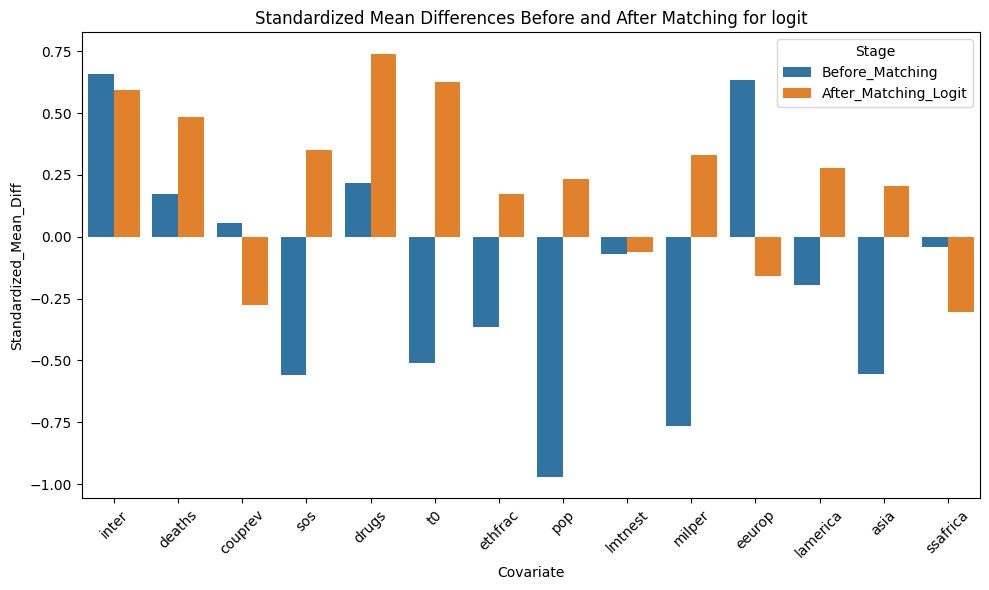

In [41]:
# plot diffs before and after matching
diffs_df = pd.DataFrame({
    'Covariate': covariates,
    'Before_Matching': [diffs_before[cov] for cov in covariates],
    'After_Matching_Logit': [diffs_after_logit[cov] for cov in covariates],
})
if diffs_after_rf:
    diffs_df['After_Matching_RF'] = [diffs_after_rf[cov] for cov in covariates]
    
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(figsize=(10, 6))
diffs_df_melted = diffs_df.melt(id_vars='Covariate', var_name='Stage', value_name='Standardized_Mean_Diff')
sns.barplot(data=diffs_df_melted, x='Covariate', y='Standardized_Mean_Diff', hue='Stage', ax=ax)
plt.xticks(rotation=45)
plt.title('Standardized Mean Differences Before and After Matching for logit')
plt.tight_layout()
plt.show()

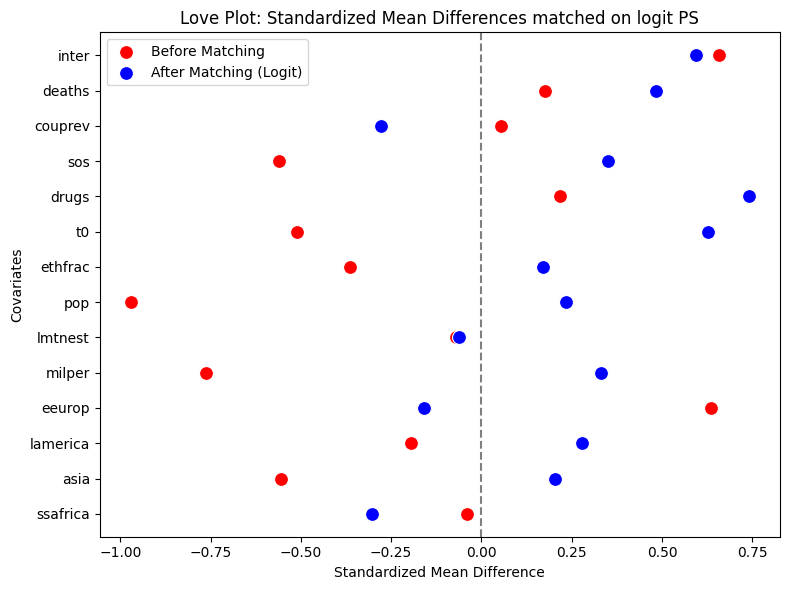

In [42]:
# love plot
fig, ax = plt.subplots(figsize=(8, 6))
covariate_order = diffs_df['Covariate']
sns.scatterplot(x='Before_Matching', y='Covariate', data=diffs_df, label='Before Matching', color='red', s=100)
sns.scatterplot(x='After_Matching_Logit', y='Covariate', data=diffs_df, label='After Matching (Logit)', color='blue', s=100)
if 'After_Matching_RF' in diffs_df:
    sns.scatterplot(x='After_Matching_RF', y='Covariate', data=diffs_df, label='After Matching (RF)', color='green', s=100)
plt.axvline(x=0, color='grey', linestyle='--')
plt.title('Love Plot: Standardized Mean Differences matched on logit PS')
plt.xlabel('Standardized Mean Difference')
plt.ylabel('Covariates')
plt.legend()
plt.tight_layout()
plt.show()

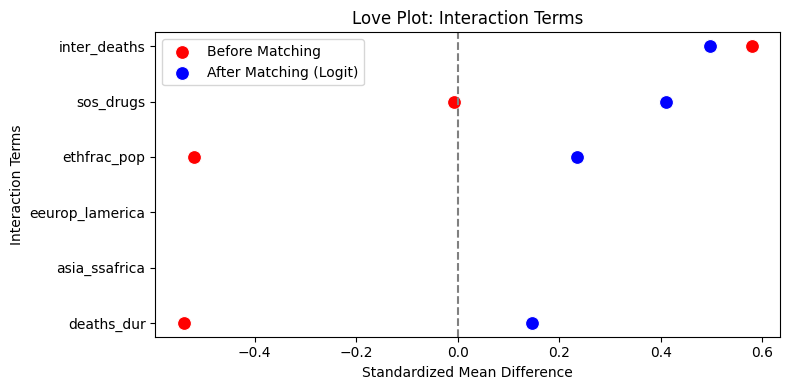

In [43]:
# love plot for interaction terms
interaction_terms = {
    'inter_deaths': ('inter', 'deaths'),
    'sos_drugs': ('sos', 'drugs'),
    'ethfrac_pop': ('ethfrac', 'pop'),
    'eeurop_lamerica': ('eeurop', 'lamerica'),
    'asia_ssafrica': ('asia', 'ssafrica'),
    'deaths_dur': ('deaths', 'dur'), 

}

# create interaction terms in original data (if missing)
for name, (left, right) in interaction_terms.items():
    data[name] = data[left] * data[right]

# ensure matched datasets have the interaction columns
def ensure_interactions_in_matched(df, interactions, treat_prefix='t_', control_prefix='c_'):
    if df.empty:
        return df
    for name, (left, right) in interactions.items():
        df[f'{treat_prefix}{name}'] = df[f'{treat_prefix}{left}'] * df[f'{treat_prefix}{right}']
        df[f'{control_prefix}{name}'] = df[f'{control_prefix}{left}'] * df[f'{control_prefix}{right}']
    return df

matched_logit = ensure_interactions_in_matched(matched_logit, interaction_terms)
matched_rf = ensure_interactions_in_matched(matched_rf, interaction_terms)

interaction_names = list(interaction_terms.keys())
diffs_before_inter = calc_diff_means(data, interaction_names)
diffs_after_logit_inter = calc_diff_means_matched(matched_logit, interaction_names)

diffs_df_inter = pd.DataFrame({
    'Covariate': interaction_names,
    'Before_Matching': [diffs_before_inter[cov] for cov in interaction_names],
    'After_Matching_Logit': [diffs_after_logit_inter[cov] for cov in interaction_names],
})

fig, ax = plt.subplots(figsize=(8, 4))
covariate_order = diffs_df_inter['Covariate']
sns.scatterplot(x='Before_Matching', y='Covariate', data=diffs_df_inter, label='Before Matching', color='red', s=100)
sns.scatterplot(x='After_Matching_Logit', y='Covariate', data=diffs_df_inter, label='After Matching (Logit)', color='blue', s=100)
plt.axvline(x=0, color='grey', linestyle='--')
plt.title('Love Plot: Interaction Terms')
plt.xlabel('Standardized Mean Difference')
plt.ylabel('Interaction Terms')
plt.legend()
plt.tight_layout()
plt.show()


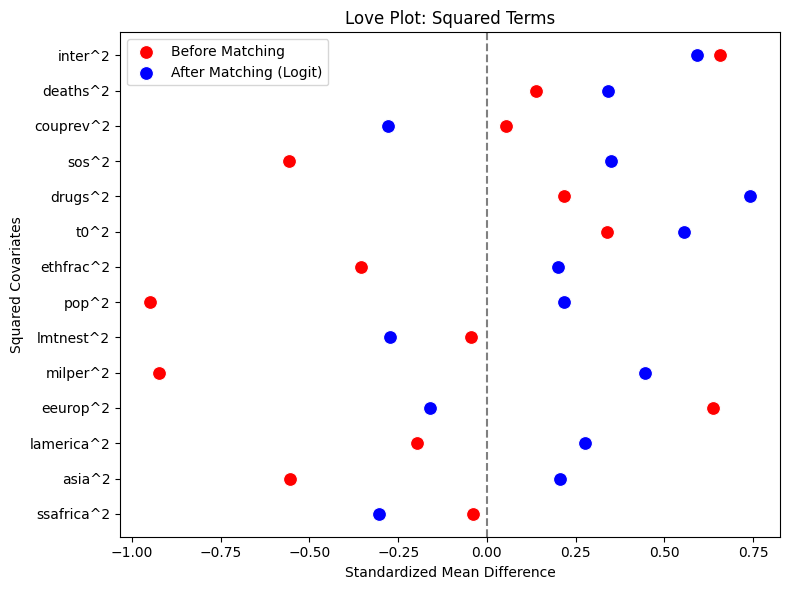

In [44]:
# love plot for square terms
square_covariates = [f"{cov}_sq" for cov in covariates]
for base, sq in zip(covariates, square_covariates):
    data[sq] = data[base] ** 2
    matched_logit[f't_{sq}'] = matched_logit[f't_{base}'] ** 2
    matched_logit[f'c_{sq}'] = matched_logit[f'c_{base}'] ** 2
    if not matched_rf.empty:
        matched_rf[f't_{sq}'] = matched_rf[f't_{base}'] ** 2
        matched_rf[f'c_{sq}'] = matched_rf[f'c_{base}'] ** 2

diffs_df_sq = pd.DataFrame({
    'Covariate': [cov.replace('_sq', '^2') for cov in square_covariates],
    'Before_Matching': [calc_diff_means(data, square_covariates)[cov] for cov in square_covariates],
    'After_Matching_Logit': [calc_diff_means_matched(matched_logit, square_covariates)[cov] for cov in square_covariates]
})

if not matched_rf.empty:
    rf_sq = calc_diff_means_matched(matched_rf, square_covariates)
    diffs_df_sq['After_Matching_RF'] = [rf_sq[cov] for cov in square_covariates]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=diffs_df_sq, x='Before_Matching', y='Covariate', label='Before Matching', color='red', s=100)
sns.scatterplot(data=diffs_df_sq, x='After_Matching_Logit', y='Covariate', label='After Matching (Logit)', color='blue', s=100)
if 'After_Matching_RF' in diffs_df_sq:
    sns.scatterplot(data=diffs_df_sq, x='After_Matching_RF', y='Covariate', label='After Matching (RF)', color='green', s=100)
plt.axvline(0, color='grey', linestyle='--')
plt.title('Love Plot: Squared Terms')
plt.xlabel('Standardized Mean Difference')
plt.ylabel('Squared Covariates')
plt.legend()
plt.tight_layout()
plt.show()

#### Common-support assessment

The original overlap table reports **75% of treated observations inside the logistic controls' score range**, compared with **0% under the fitted forest**. For controls, the corresponding proportions inside the treated range are about **82.1%** and **0%**.

Min–max overlap is a coarse diagnostic, not proof of adequate local control density or balance. The forest's failure to match limits what can be estimated under that design; it is not evidence that intervention has no effect.

,Treated min,Treated max,Control min,Control max,Treated inside control support,Control inside treated support
Method,,,,,,
Logit,0.000923,0.576755,0.000224,0.150716,0.75,0.820809
Random Forest,0.610000,0.830000,0.000000,0.100000,0.00,0.000000


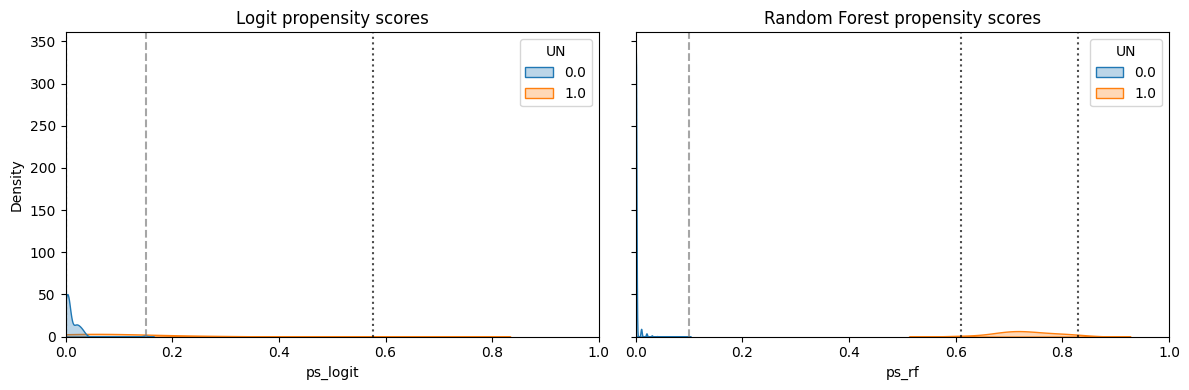

Logit: 25.0% of treated outside control support, 17.9% of controls outside treated support.
Random Forest: 100.0% of treated outside control support, 100.0% of controls outside treated support.


In [45]:
# Q4 — Propensity score overlap diagnostics
ps_methods = {
    'Logit': 'ps_logit',
    'Random Forest': 'ps_rf'
}

rows = []
for method, col in ps_methods.items():
    treated = data.loc[data['UN'] == 1, col]
    control = data.loc[data['UN'] == 0, col]

    control_min, control_max = control.min(), control.max()
    treated_min, treated_max = treated.min(), treated.max()

    prop_treated_in_control = ((treated >= control_min) & (treated <= control_max)).mean()
    prop_control_in_treated = ((control >= treated_min) & (control <= treated_max)).mean()

    rows.append({
        'Method': method,
        'Treated min': treated_min,
        'Treated max': treated_max,
        'Control min': control_min,
        'Control max': control_max,
        'Treated inside control support': prop_treated_in_control,
        'Control inside treated support': prop_control_in_treated,
    })

overlap_df = pd.DataFrame(rows).set_index('Method')
display(overlap_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (method, col) in zip(axes, ps_methods.items()):
    sns.kdeplot(data=data, x=col, hue='UN', fill=True, common_norm=False, alpha=0.3, ax=ax)
    ax.set_title(f'{method} propensity scores')
    ax.set_xlim(0, 1)

    treated = data.loc[data['UN'] == 1, col]
    control = data.loc[data['UN'] == 0, col]
    ax.axvline(control.min(), color='grey', linestyle='--', alpha=0.7)
    ax.axvline(control.max(), color='grey', linestyle='--', alpha=0.7)
    ax.axvline(treated.min(), color='black', linestyle=':', alpha=0.7)
    ax.axvline(treated.max(), color='black', linestyle=':', alpha=0.7)
    ax.legend_.set_title('UN')

plt.tight_layout()
plt.show()
for row in rows:
    treated_gap = 1 - row['Treated inside control support']
    control_gap = 1 - row['Control inside treated support']
    print(f"{row['Method']}: {treated_gap:.1%} of treated outside control support, {control_gap:.1%} of controls outside treated support.")


### 4. Outcome comparisons after matching

The analysis compares duration within matched sets and examines sensitivity to the requested number of controls. Because only 13 treated observations remain and important imbalances persist, numerical estimates should be read as exploratory matched contrasts.

#### Matched-treated average contrast

For treated observations with a valid match, the one-to-one comparison is

$$\widehat\tau=\frac{1}{N_T^*}\sum_{i\in\mathcal T^*}\left(Y_i-Y_{j(i)}\right).$$

It estimates a causal effect for the retained treated population only if the identification and measurement assumptions hold. A negative value corresponds to shorter observed duration in treated snapshots than in their matched controls.

#### Sensitivity to the number of controls

The code requests one, two, or three controls per treated observation. It accepts fewer than the requested number if only a smaller number lie within the caliper. The labels “1:2” and “1:3” therefore represent **up to two or three controls**, not guaranteed fixed ratios.

For a matched treated unit $i$ with $m_i$ accepted controls, the equal-treated comparison averages

$$Y_i-\frac{1}{m_i}\sum_{j\in\mathcal J(i)}Y_j.$$

This gives every matched treated observation equal weight even when its number of controls differs. The later unweighted pooled regression does not generally use the same weighting when matched-set sizes vary.

Additional controls can reduce outcome noise when they are sufficiently comparable. They can also worsen comparability when progressively more distant controls are included. Which tradeoff dominates depends on the sample and design; one neighbor does not universally minimize causal bias.

Mean matching distance is a diagnostic of proximity, not a measured bias estimate. Changes in point estimates across ratios do not establish a bias–variance relationship by themselves.

#### Comparing retained samples, distances, and estimates

The first table uses the **equal-treated average of matched-set differences**. The second table fits an **unweighted pooled outcome-on-treatment regression** and reports matched-set-clustered standard errors. Their estimates differ for variable-sized sets, so they should not be treated as interchangeable calculations of the same statistic.

All saved interval values and plot labels below remain as originally produced. The duration unit is months as established by the supplied dates, even where retained labels say “days.”

In [46]:
# Function for m:1 matching
def nn_matching_m_to_1(data, treatment_df, control_df, ps_col, m=1, caliper_sd=0.2):
    """
    Perform 1:m nearest neighbor matching with caliper
    
    Parameters:
    -----------
    data : DataFrame with all data
    treatment_df : DataFrame with treated units
    control_df : DataFrame with control units
    ps_col : column name for propensity score (or logit-transformed PS)
    m : number of controls to match per treated unit
    caliper_sd : caliper size in standard deviations
    
    Returns:
    --------
    DataFrame with matched units and distances
    """
    caliper = caliper_sd * data[ps_col].std()
    
    matched_pairs = []
    for _, tunit in treatment_df.iterrows():
        # Calculate distances to all controls
        distances = []
        for _, cunit in control_df.iterrows():
            dist = abs(tunit[ps_col] - cunit[ps_col])
            distances.append((cunit['id'], dist))
        
        # Sort by distance and take m closest within caliper
        distances.sort(key=lambda x: x[1])
        
        matches_in_caliper = []
        for control_id, dist in distances[:m]:
            if dist <= caliper:
                matches_in_caliper.append((control_id, dist))
        
        if len(matches_in_caliper) > 0:
            control_ids = [c_id for c_id, _ in matches_in_caliper]
            dists = [d for _, d in matches_in_caliper]
            matched_pairs.append({
                'treated_id': tunit['id'],
                'control_ids': control_ids,
                'mean_distance': np.mean(dists),
                'n_controls': len(control_ids)
            })
    
    return pd.DataFrame(matched_pairs)

def compute_att_m_to_1(matched_df, data, outcome='dur'):
    """
    Compute ATT for m:1 matching
    """
    if len(matched_df) == 0:
        return np.nan, 0, np.nan
    
    differences = []
    for _, row in matched_df.iterrows():
        treated_outcome = data.loc[row['treated_id'], outcome]
        control_outcomes = data.loc[row['control_ids'], outcome].values
        avg_control = np.mean(control_outcomes)
        differences.append(treated_outcome - avg_control)
    
    att = np.mean(differences)
    mean_distance = matched_df['mean_distance'].mean()
    
    return att, len(differences), mean_distance

# Separate treatment and control groups
treatment = data[data['UN'] == 1].copy()
control = data[data['UN'] == 0].copy()

# Test 1:1, 1:2, and 1:3 matching
print("\n1. Running matching for different ratios:")
print(f"\n{'Ratio':<10} {'N Matched':<12} {'Mean Dist':<15} {'ATT Est.':<12}")
print("-" * 55)

ratio_results = []
for m in [1, 2, 3]:
    matched_m = nn_matching_m_to_1(data, treatment, control, 
                                     'logit_ps_logit', m=m)
    att_m, n_m, dist_m = compute_att_m_to_1(matched_m, data)
    
    ratio_results.append({
        'ratio': f'1:{m}',
        'm': m,
        'n_matched': n_m,
        'mean_distance': dist_m,
        'att': att_m
    })
    
    print(f"1:{m:<8} {n_m:<12} {dist_m:<15.4f} {att_m:<12.3f}")

print("\n2. Observations:")
print("   - Mean distance increases from 1:1 to 1:3 (worse match quality)")
print("   - ATT estimates vary across specifications")
print("   - Demonstrates the bias-variance tradeoff empirically")


1. Running matching for different ratios:

Ratio      N Matched    Mean Dist       ATT Est.    
-------------------------------------------------------
1:1        13           0.0853          -2.923      
1:2        13           0.0862          1.846       
1:3        13           0.0918          6.769       

2. Observations:
   - Mean distance increases from 1:1 to 1:3 (worse match quality)
   - ATT estimates vary across specifications
   - Demonstrates the bias-variance tradeoff empirically


In [47]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.sandwich_covariance import cov_cluster
from scipy import stats


def compute_cluster_robust_m_to_1(matched_df, data, m):
    """
    Compute cluster-robust SE for m:1 matching
    Each cluster = 1 treated unit + its m matched controls
    """
    if len(matched_df) == 0:
        return None, None
    
    # Create matched dataset
    matched_data = []
    for idx, row in matched_df.iterrows():
        # Add treated unit
        matched_data.append({
            'outcome': data.loc[row['treated_id'], 'dur'],
            'treatment': 1,
            'subclass': idx  # Cluster ID
        })
        # Add control units
        for c_id in row['control_ids']:
            matched_data.append({
                'outcome': data.loc[c_id, 'dur'],
                'treatment': 0,
                'subclass': idx  # Same cluster ID
            })
    
    df_reg = pd.DataFrame(matched_data)
    
    # Fit regression: Y ~ Treatment
    y_reg = df_reg['outcome'].values
    X_reg = sm.add_constant(df_reg['treatment'].values)
    
    model = OLS(y_reg, X_reg)
    results = model.fit()
    
    # Cluster-robust SEs
    clusters = df_reg['subclass'].values
    cov_robust = cov_cluster(results, clusters, use_correction=True)
    se_robust = np.sqrt(np.diag(cov_robust))
    
    return results.params[1], se_robust[1]

print(f"\n{'Ratio':<10} {'N Pairs':<12} {'ATT':<12} {'Robust SE':<12} {'95% CI'}")
print("-" * 70)

for m in [1, 2, 3]:
    matched_m = nn_matching_m_to_1(data, treatment, control, 
                                     'logit_ps_logit', m=m)
    tau_m, se_m = compute_cluster_robust_m_to_1(matched_m, data, m)
    
    if tau_m is not None:
        ci_l = tau_m - 1.96 * se_m
        ci_u = tau_m + 1.96 * se_m
        print(f"1:{m:<8} {len(matched_m):<12} {tau_m:<12.3f} {se_m:<12.3f} [{ci_l:.2f}, {ci_u:.2f}]")

print("\n3. Pattern observed:")
print("   - Standard errors are similar across ratios (small sample)")



Ratio      N Pairs      ATT          Robust SE    95% CI
----------------------------------------------------------------------
1:1        13           -2.923       13.216       [-28.83, 22.98]
1:2        13           0.529        12.994       [-24.94, 26.00]
1:3        13           5.256        13.238       [-20.69, 31.20]

3. Pattern observed:
   - Standard errors are similar across ratios (small sample)


   Saved: bias_variance_tradeoff.png


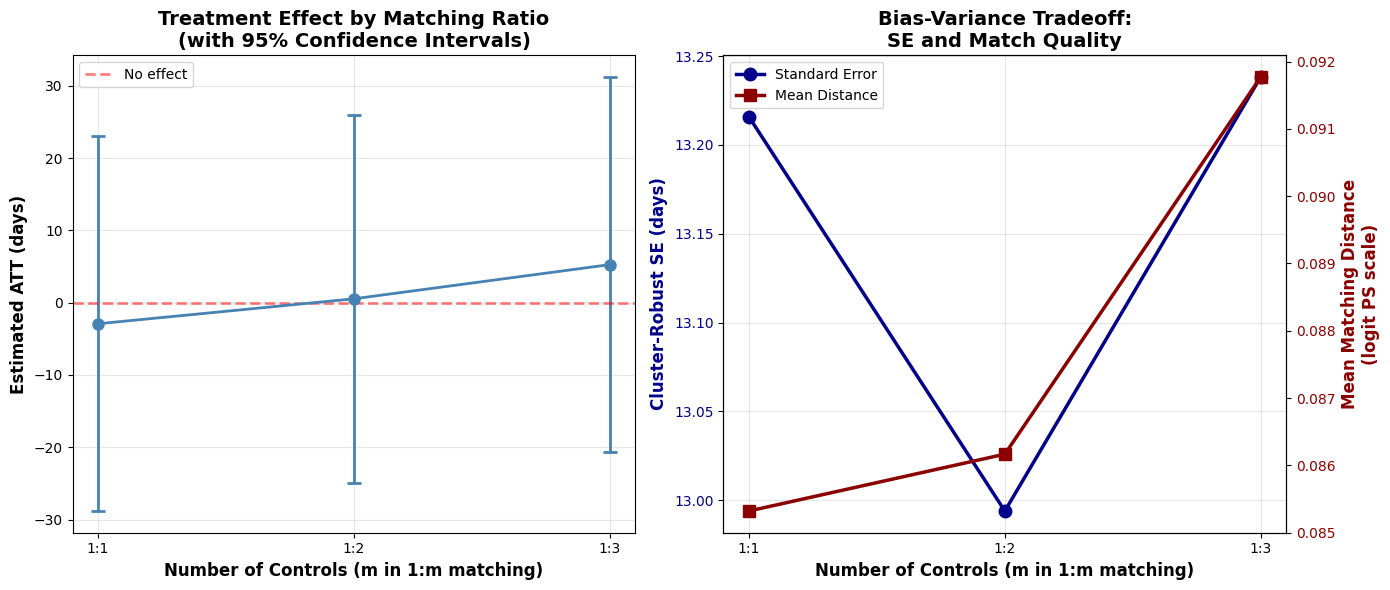

In [48]:
import matplotlib.pyplot as plt

# Recompute with SEs for plotting
m_values = []
att_values = []
se_values = []
dist_values = []

for m in [1, 2, 3]:
    matched_m = nn_matching_m_to_1(data, treatment, control, 
                                     'logit_ps_logit', m=m)
    tau_m, se_m = compute_cluster_robust_m_to_1(matched_m, data, m)
    att_m, n_m, dist_m = compute_att_m_to_1(matched_m, data)
    
    m_values.append(m)
    att_values.append(tau_m)
    se_values.append(se_m)
    dist_values.append(dist_m)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ATT with error bars
ax1.errorbar(m_values, att_values, yerr=1.96*np.array(se_values), 
             fmt='o-', capsize=5, capthick=2, markersize=8, linewidth=2,
             color='steelblue', ecolor='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=2, 
            label='No effect')
ax1.set_xlabel('Number of Controls (m in 1:m matching)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Estimated ATT (days)', fontsize=12, fontweight='bold')
ax1.set_title('Treatment Effect by Matching Ratio\n(with 95% Confidence Intervals)', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(m_values)
ax1.set_xticklabels([f'1:{m}' for m in m_values])
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: SE and Distance (dual y-axis)
ax2_twin = ax2.twinx()

l1 = ax2.plot(m_values, se_values, 'o-', color='darkblue', 
              linewidth=2.5, markersize=9, label='Standard Error')
l2 = ax2_twin.plot(m_values, dist_values, 's-', color='darkred', 
                   linewidth=2.5, markersize=9, label='Mean Distance')

ax2.set_xlabel('Number of Controls (m in 1:m matching)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cluster-Robust SE (days)', fontsize=12, fontweight='bold', 
               color='darkblue')
ax2_twin.set_ylabel('Mean Matching Distance\n(logit PS scale)', fontsize=12, 
                    fontweight='bold', color='darkred')
ax2.set_title('Bias-Variance Tradeoff:\nSE and Match Quality', 
              fontsize=14, fontweight='bold')
ax2.set_xticks(m_values)
ax2.set_xticklabels([f'1:{m}' for m in m_values])
ax2.tick_params(axis='y', labelcolor='darkblue')
ax2_twin.tick_params(axis='y', labelcolor='darkred')
ax2.grid(True, alpha=0.3)

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('bias_variance_tradeoff.png', dpi=300, bbox_inches='tight')
print("   Saved: bias_variance_tradeoff.png")
plt.show()



#### Results across matching ratios

| Requested maximum controls | Matched treated | Equal-treated contrast | Pooled regression contrast | Reported clustered SE |
|---|---:|---:|---:|---:|
| 1 | 13 | −2.923 | −2.923 | 13.216 |
| 2 | 13 | 1.846 | 0.529 | 12.994 |
| 3 | 13 | 6.769 | 5.256 | 13.238 |

Values are in months. Mean match distance increases from approximately **0.0853** to **0.0918**. These figures are transcribed from saved outputs; no matching models were rerun.

The reported pooled-regression intervals all include zero: approximately **[−28.83, 22.98]**, **[−24.94, 26.00]**, and **[−20.69, 31.20]**. They show considerable imprecision under the implemented calculations. This is not proof of no causal effect.

The standard errors do not decrease monotonically with the requested number of controls. In addition, shared controls and repeated source conflict IDs create dependence that simple matched-set clustering does not necessarily capture. Residual covariate imbalance further limits a causal interpretation.

#### Post-matching regression and uncertainty

The next function fits $Y_i=\alpha+\tau T_i+\epsilon_i$ in the matched data and clusters by the treated observation's matched-set ID.

This is the inference approach implemented in the notebook, not a claim that it satisfies every condition of post-matching inference theory. Matching uses replacement: one control can occur in multiple clusters, while source conflicts can contribute repeated rows. Clustering only by matched set does not automatically account for those links. The code does not implement an HC3 correction.

In [49]:
import pandas as pd
import statsmodels.formula.api as smf

def cluster_ols_att_grouped(data, matched_df, outcome_col="dur"):
    """
    Abadie & Spiess–style post-matching inference.
    Builds a long dataset with one row per matched observation
    and estimates Y ~ T with cluster-robust SEs.
    
    Parameters
    ----------
    data : DataFrame with full sample (must contain 'id', outcome_col)
    matched_df : DataFrame with columns 'treated_id', 'control_id'
    outcome_col : name of outcome variable (e.g. 'dur' or 'ldur')
    
    Returns
    -------
    tau_hat : estimated ATT (coef on T)
    se_hat  : cluster-robust standard error
    model   : full statsmodels result (if you want to inspect)
    """
    if matched_df is None or matched_df.empty:
        return None, None, None
    
    d_idx = data.set_index("id")
    rows = []

    for _, row in matched_df.iterrows():
        tid = row["treated_id"]
        cid = row["control_id"]
        gid = tid             # cluster/subclass id = treated unit id

        # treated observation
        rows.append({"Y": d_idx.at[tid, outcome_col],
                     "T": 1,
                     "group": gid})
        # control observation
        rows.append({"Y": d_idx.at[cid, outcome_col],
                     "T": 0,
                     "group": gid})

    df_long = pd.DataFrame(rows).drop_duplicates()

    model = smf.ols("Y ~ T", data=df_long).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_long["group"]}
    )
    tau_hat = model.params["T"]
    se_hat = model.bse["T"]
    return tau_hat, se_hat, model


In [50]:
outcome = "dur"  # outcome variable

tau_logit, se_logit, model_logit = cluster_ols_att_grouped(
    data, matched_df, outcome_col=outcome
)

tau_rf, se_rf, model_rf = cluster_ols_att_grouped(
    data, matched_df_rf, outcome_col=outcome
)

print(f"Logit matching: tau = {tau_logit:.3f},  SE(cluster) = {se_logit:.3f}")
if tau_rf is not None and se_rf is not None:
    print(f"RF matching: tau = {tau_rf:.3f},  SE(cluster) = {se_rf:.3f}")
else:
    print("RF matching: no valid matched pairs (matched_df_rf is empty) – ATT not defined.")


Logit matching: tau = -2.923,  SE(cluster) = 13.216
RF matching: no valid matched pairs (matched_df_rf is empty) – ATT not defined.


The saved one-to-one logistic result is **−2.923 months**, with a reported matched-set-clustered standard error of **13.216 months**. The forest result is undefined because no valid pairs were found.

The main lesson is that credible counterfactual construction requires both usable support and satisfactory balance. A treatment classifier's high accuracy cannot substitute for either, and the reported standard errors do not remove the design limitations above.

#### Further inference work

A bootstrap is not implemented in this notebook. Any future resampling procedure would need a justification for nearest-neighbor matching, reused controls, and repeated conflict observations. No bootstrap estimates or confidence intervals are claimed here.

### 5. What the matching case study establishes

The project demonstrates a full workflow from assignment modeling through matching, overlap checks, balance diagnostics, and outcome comparison. Its saved results expose important limitations rather than establishing a definitive effect of UN intervention on completed war duration.

#### Identification considerations

The true propensity score balances measured covariates in the population. Estimated scores need not produce balance in a finite matched sample, so balance must be checked directly. A causal ATT interpretation also requires adequate untreated support for the treated profiles and a credible conditional-exchangeability assumption.

In this implementation, logistic scores retain enough proximity to match 13 treated observations, while the in-sample random forest separates treatment groups too sharply to yield matches. This is a finding about these fitted models, not a universal comparison of model families.

Substantial residual imbalance, only 16 treated observations overall, repeated source periods, and unmodeled censoring prevent a strong causal conclusion. The useful takeaway is how design diagnostics can limit interpretation even when a numerical estimate can be calculated.

## Case study 2 — German reunification and synthetic control

The second application constructs a weighted donor-country comparison for West Germany's GDP per capita. It contrasts unconstrained regression weights with a nonnegative, sum-to-one synthetic control, then examines country-placebo and earlier-cutoff diagnostics.

Implementation guidance was drawn from Matheus Facure's [Synthetic Control chapter](https://matheusfacure.github.io/python-causality-handbook/15-Synthetic-Control.html), as acknowledged in the original notebook. The supplied data are `data/repgermany.dta`.

### 1. Counterfactual construction

A synthetic control combines donor trajectories to approximate a treated unit before exposure. Here the supplied panel contains **17 countries over 1960–2003**, with West Germany as the treated unit and 16 possible donors.

A close fitted pre-period path is useful but insufficient for causal identification. The comparison also requires a stable untreated relationship after the cutoff, a suitable donor pool, no relevant spillovers or anticipation, and no other treated-unit-specific shock that explains the gap.

**Timing:** the original code defines post-treatment as `year > 1990`, meaning **1990 is included in fitting**. This convention is preserved even though reunification occurred during 1990.

### 2. Donor-weight optimization

The constrained fit minimizes pre-cutoff prediction error:

$$\min_w\sqrt{\frac{1}{T_0}\sum_{t\leq 1990}\left(Y_{West,t}-\sum_jw_jY_{jt}\right)^2},
\qquad w_j\geq0,\quad\sum_jw_j=1.$$

The code minimizes RMSE, which has the same minimizer as MSE for the same residuals. Nonnegative weights summing to one define a convex combination of donors. By contrast, the preliminary regression permits negative weights and does not require them to sum to one.

The implemented optimization uses **only the GDP-per-capita trajectory**, not a separately optimized predictor-weight matrix or entropy balancing. Additional variables appear later in a descriptive balance table; they are not fitted constraints.

### 3. Fitting and inspecting the synthetic trajectory

The following cells load the country panel, inspect missingness, fit an unconstrained benchmark, and then construct the constrained synthetic control. The saved unconstrained weights include negative values and sum to about **0.8442**. The constrained weights sum to approximately **1.0000**.

The GDP series is complete; several other predictors have substantial missingness. No imputation or optimization over those predictors is implemented. The code imports `rpy2`, so a compatible R installation is needed for a fresh execution even though donor optimization uses SciPy.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations
import plotnine as p
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [52]:
data = pd.read_stata('data/repgermany.dta')
data['west_germany'] = (data['country'] == 'West Germany')
data['after_treatment'] = (data['year'] > 1990)

In [53]:
data

,index,country,year,gdp,infrate,trade,schooling,invest60,invest70,invest80,industry,west_germany,after_treatment
0,1.0,USA,1960.0,2879,NaN,9.693181,43.799999,NaN,NaN,NaN,NaN,False,False
1,1.0,USA,1961.0,2929,1.075182,9.444654,NaN,NaN,NaN,NaN,NaN,False,False
2,1.0,USA,1962.0,3103,1.116071,9.429324,NaN,NaN,NaN,NaN,NaN,False,False
3,1.0,USA,1963.0,3227,1.214128,9.470706,NaN,NaN,NaN,NaN,NaN,False,False
4,1.0,USA,1964.0,3420,1.308615,9.725879,NaN,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
743,21.0,New Zealand,1999.0,19937,-0.124595,NaN,NaN,NaN,NaN,NaN,25.512980,False,True
744,21.0,New Zealand,2000.0,20789,2.619761,NaN,26.299999,NaN,NaN,NaN,25.291679,False,True
745,21.0,New Zealand,2001.0,21825,2.625821,NaN,NaN,NaN,NaN,NaN,NaN,False,True
746,21.0,New Zealand,2002.0,22662,2.677091,NaN,NaN,NaN,NaN,NaN,NaN,False,True


In [54]:
data.isna().sum() # A lot of NaN values in invest and schooling variables

index                0
country              0
year                 0
gdp                  0
infrate             21
trade              102
schooling          597
invest60           731
invest70           731
invest80           731
industry           207
west_germany         0
after_treatment      0
dtype: int64

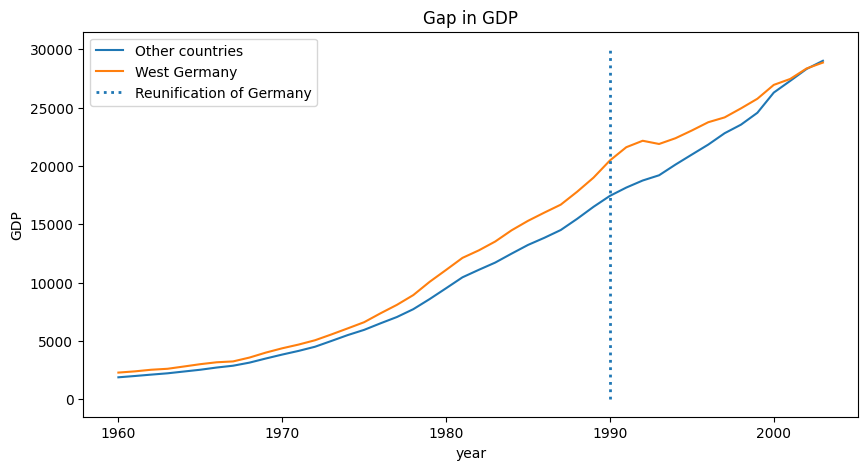

In [55]:
ax = plt.subplot(1, 1, 1)

(data
 .assign(west_germany = np.where(data["country"] == "West Germany", "West Germany", "Other countries"))
 .pivot_table(index="year", columns="west_germany", values="gdp", aggfunc="mean")
 .plot(ax=ax, figsize=(10,5)))

plt.vlines(x=1990, ymin=1, ymax=30000, linestyle=":", lw=2, label="Reunification of Germany")
plt.ylabel("GDP")
plt.title("Gap in GDP")
plt.legend()

In [56]:
features = ["gdp"]#, "infrate", "trade", "schooling"]#	"invest60",	"invest70",	"invest80",	"industry"]

inverted = (data.query("~after_treatment") # filter pre-intervention period
            .pivot(index='index', columns="year")[features] # make one column per year and one row per state
            .T) # flip the table to have one column per state

inverted.head()

y = inverted[7].values # west germany
X = inverted.drop(columns=7).values  # other countries

In [57]:
from sklearn.linear_model import LinearRegression
weights_lr = LinearRegression(fit_intercept=False).fit(X, y).coef_
west_germany_synth_lr = (data.query("~west_germany")
                  .pivot(index='year', columns="index")["gdp"]
                  .values.dot(weights_lr))

In [58]:
weights_lr # As we can see we have negative values of weights and the sum is necessary is 1. It means that we used extrapolation

array([ 0.29530769,  0.08956337,  0.15136974,  0.27271208,  0.04412137,
        0.12717095,  0.23291936,  0.33102011, -0.02327215,  0.10246034,
       -0.07091371, -0.04359574, -0.06027154, -0.3103372 , -0.1763318 ,
       -0.11767821])

In [59]:
sum(weights_lr)

np.float64(0.8442446567145467)

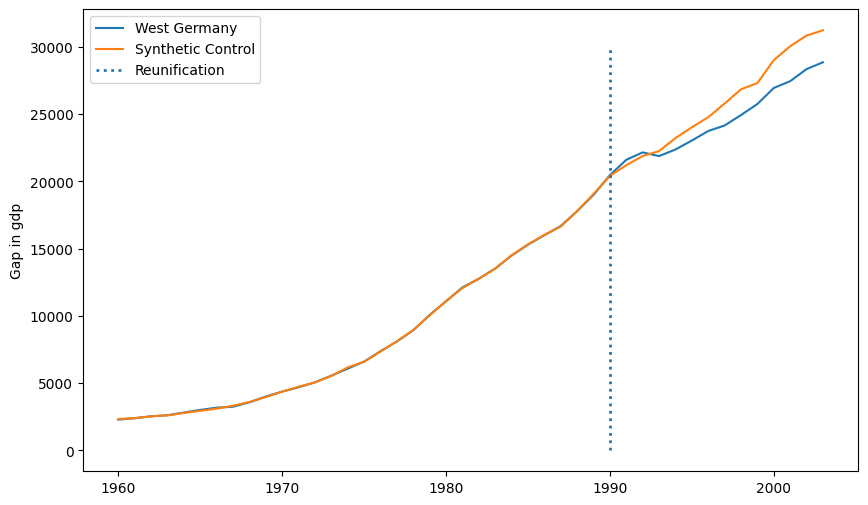

In [60]:
plt.figure(figsize=(10,6))
plt.plot(data.query("west_germany")["year"], data.query("west_germany")["gdp"], label="West Germany")
plt.plot(data.query("west_germany")["year"], west_germany_synth_lr, label="Synthetic Control")
plt.vlines(x=1990, ymin=1, ymax=30000, linestyle=":", lw=2, label="Reunification")
plt.ylabel("Gap in gdp")
plt.legend();

In [61]:
from typing import List
from operator import add
from toolz import reduce, partial
from scipy.optimize import fmin_slsqp

def loss_w(W, X, y) -> float:
    return np.sqrt(np.mean((y - X.dot(W))**2))


def get_w(X, y):

    w_start = [1/X.shape[1]]*X.shape[1]

    weights = fmin_slsqp(partial(loss_w, X=X, y=y),
                         np.array(w_start),
                         f_eqcons=lambda x: np.sum(x) - 1,
                         bounds=[(0.0, 1.0)]*len(w_start),
                         disp=False)
    return weights


west_germany_weights = get_w(X, y)
print("Sum:", west_germany_weights.sum())
np.round(west_germany_weights, 4)

Sum: 1.0000000002737948


array([0.2728, 0.    , 0.2911, 0.    , 0.    , 0.0303, 0.1914, 0.133 ,
       0.    , 0.0814, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ])

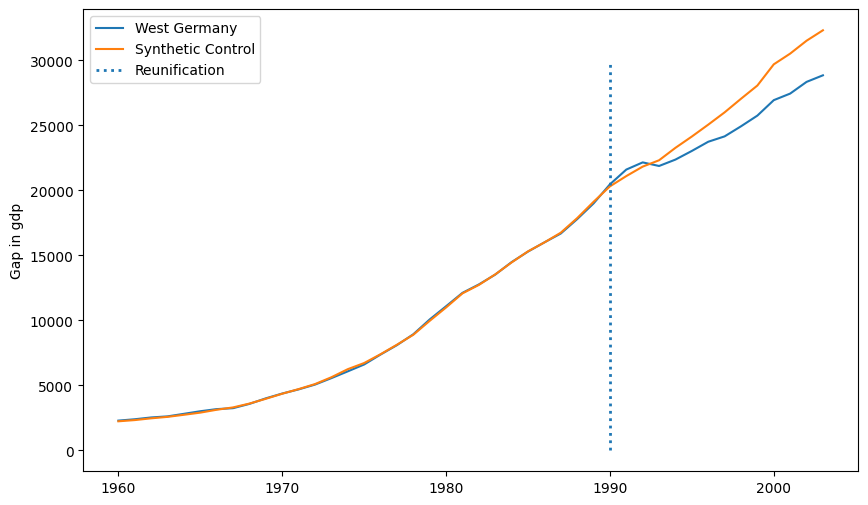

In [62]:
west_germany_synth = data.query("~west_germany").pivot(index='year', columns="index")["gdp"].values.dot(west_germany_weights)

plt.figure(figsize=(10,6))
plt.plot(data.query("west_germany")["year"], data.query("west_germany")["gdp"], label="West Germany")
plt.plot(data.query("west_germany")["year"], west_germany_synth, label="Synthetic Control")
plt.vlines(x=1990, ymin=1, ymax=30000, linestyle=":", lw=2, label="Reunification")
plt.ylabel("Gap in gdp")
plt.legend();

#### Descriptive predictor comparison

The next section applies the GDP-fitted donor weights to other fields. Missing values can propagate through the weighted matrix products, even for zero-weight donors. The saved empty-slice warnings and NaN values are retained and mean that the table is not a complete balance assessment.

In [63]:
data[data['index'].isin([1.0, 3.0, 6.0,7.0,8.0, 10.0])].isna().sum() # We could calculate balance table but for countries that have non-zero weights there are many NA so we should keep it in mind

index                0
country              0
year                 0
gdp                  0
infrate             10
trade               41
schooling          212
invest60           258
invest70           258
invest80           258
industry            80
west_germany         0
after_treatment      0
dtype: int64

In [64]:
west_germany_synth = data.query("~west_germany").pivot(index='year', columns="index")["gdp"].values.dot(west_germany_weights)
features = ["gdp", "infrate", "trade", "schooling",	"invest60",	"invest70",	"invest80",	"industry"]
balance_data = []

for feature in features:
  new_dict = {}
  pre_treatment = data[data['year'] <= 1990.0]
  post_treatment = data[data['year'] > 1990.0]
  pre_treatment_wg = pre_treatment.query("west_germany").pivot(index='year', columns="index")[feature]
  post_treatment_wg = post_treatment.query("west_germany").pivot(index='year', columns="index")[feature]
  west_germany_pre_synth =pre_treatment.query("~west_germany").pivot(index='year', columns="index")[feature].values.dot(west_germany_weights)
  west_germany_post_synth = post_treatment.query("~west_germany").pivot(index='year', columns="index")[feature].values.dot(west_germany_weights)
  new_dict['Pre Treatment West Germany'] = np.nanmean(pre_treatment_wg)
  new_dict['Pre Treatment SYNTHETIC West Germany'] = np.nanmean(west_germany_pre_synth)
  new_dict['Post Treatment West Germany'] = np.nanmean(post_treatment_wg)
  new_dict['Post Treatment SYNTHETIC West Germany'] = np.nanmean(west_germany_post_synth)
  new_dict['Predictor'] = feature
  balance_data.append(new_dict)


/tmp/ipykernel_62100/581843642.py:15: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:15: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:15: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:16: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:15: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:16: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:15: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:16: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_62100/581843642.py:15: RuntimeWarning: Mean of empty slice


The saved pre-cutoff GDP-per-capita means are **8,566.45** for West Germany and **8,561.56** for the synthetic comparison. Their proximity is consistent with fitting the GDP trajectory, but similarity of averages does not alone establish year-by-year fit or balance on other characteristics.

The post-cutoff means are **24,709.15** and **26,377.58**, respectively. This is a descriptive separation under the fitted comparison, not an independently validated causal effect. Inflation and other predictor differences, missingness, donor suitability, and intervention timing remain relevant.

In [65]:
df = pd.DataFrame(balance_data).set_index('Predictor')
df

,Pre Treatment West Germany,Pre Treatment SYNTHETIC West Germany,Post Treatment West Germany,Post Treatment SYNTHETIC West Germany
Predictor,,,,
gdp,8566.451613,8561.555957,24709.153846,26377.582326
infrate,3.368035,5.615369,2.283912,2.589898
trade,46.163300,48.329425,NaN,57.856516
schooling,55.842861,41.679363,NaN,45.457564
invest60,0.337380,0.287943,NaN,NaN
invest70,0.325640,0.298037,NaN,NaN
invest80,27.017998,25.225440,NaN,NaN
industry,39.689518,35.490198,NaN,29.330271


#### Which donors receive weight?

The saved rounded weights are approximately **Austria 0.29**, **USA 0.27**, **Italy 0.19**, **Netherlands 0.13**, **Switzerland 0.08**, and **France 0.03**. Other donors round to zero. Rounding explains why the displayed weights do not sum to exactly one.

These weights are selected to fit the pre-cutoff GDP path. Geographic proximity or economic relationships are possible context, not demonstrated explanations of why the optimizer selected a donor.

In [66]:
donor_countries = data[data['west_germany'] != 1]['country'].unique()

# Create weights DataFrame for donor countries only
weights_df = pd.DataFrame({
    'country': donor_countries,
    'weight': np.round(west_germany_weights, 2)
})

weights_df

,country,weight
0,USA,0.27
1,UK,0.00
2,Austria,0.29
3,Belgium,0.00
4,Denmark,0.00
5,France,0.03
6,Italy,0.19
7,Netherlands,0.13
8,Norway,0.00
9,Switzerland,0.08


### 4. Post-cutoff trajectories and country-placebo diagnostics

The plots compare the observed and synthetic series, then repeat the synthetic-control construction treating each country in turn as the target. The later plot retains cases whose pre-treatment mean squared error is below **700,000**. This is the code's absolute fit threshold, not a post/pre-RMSPE ratio test.

The placebo donor pools include West Germany when another country is the target, so they can include the actually exposed unit after reunification. Comparability and exchangeability across these placebo assignments are not guaranteed.

#### Reading the gap calculations

The saved paths separate more visibly after the early 1990s. However, two printed gap summaries use **sums of absolute differences**, not signed average treatment effects. In this 1960–2003 panel, `[-12:-9]` selects **1992–1994**, and `[-12:]` selects **1992–2003**—not the first three post-1990 years or the complete 1991–2003 post-period.

The printed values of approximately **1,669.80** and **22,841.63** therefore retain their original computations but should not be labeled average causal effects.

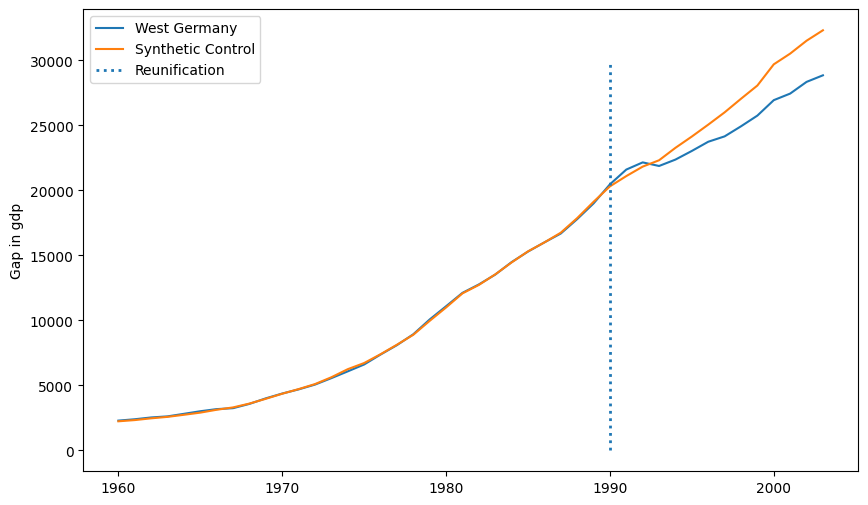

In [67]:
west_germany_synth = data.query("~west_germany").pivot(index='year', columns="index")["gdp"].values.dot(west_germany_weights)

plt.figure(figsize=(10,6))
plt.plot(data.query("west_germany")["year"], data.query("west_germany")["gdp"], label="West Germany")
plt.plot(data.query("west_germany")["year"], west_germany_synth, label="Synthetic Control")
plt.vlines(x=1990, ymin=1, ymax=30000, linestyle=":", lw=2, label="Reunification")
plt.ylabel("Gap in gdp")
plt.legend();

In [68]:
 np.array(data.query("west_germany")["gdp"])[-12:-9].mean()

np.float64(22134.333333333332)

In [69]:
print(f'The gap between synthetic and real values in first 3 years are {np.sum(np.abs(west_germany_synth[-12:-9] -  np.array(data.query("west_germany")["gdp"][-12:-9])))}')

The gap between synthetic and real values in first 3 years are 1669.7953115084638


In [70]:
print(f'The gap between synthetic and real values in post-treatment are {np.sum(np.abs(west_germany_synth[-12:] -  np.array(data.query("west_germany")["gdp"][-12:])))}')

The gap between synthetic and real values in post-treatment are 22841.63135149115


In [71]:
from joblib import Parallel, delayed

def synthetic_control(index: float, data: pd.DataFrame) -> np.array:

    features = ["gdp"]

    inverted = (data.query("~after_treatment")
                .pivot(index='index', columns="year")[features]
                .T)

    y = inverted[index].values # treated
    X = inverted.drop(columns=index).values # donor pool

    weights = get_w(X, y)
    synthetic = (data.query(f"~(index=={index})")
                 .pivot(index='year', columns="index")["gdp"]
                 .values.dot(weights))

    return (data
            .query(f"index=={index}")[["index", "year", "gdp", "after_treatment"]]
            .assign(synthetic=synthetic))



control_pool = data["index"].unique()

parallel_fn = delayed(partial(synthetic_control, data=data))

synthetic_states = Parallel(n_jobs=8)(parallel_fn(index) for index in control_pool)

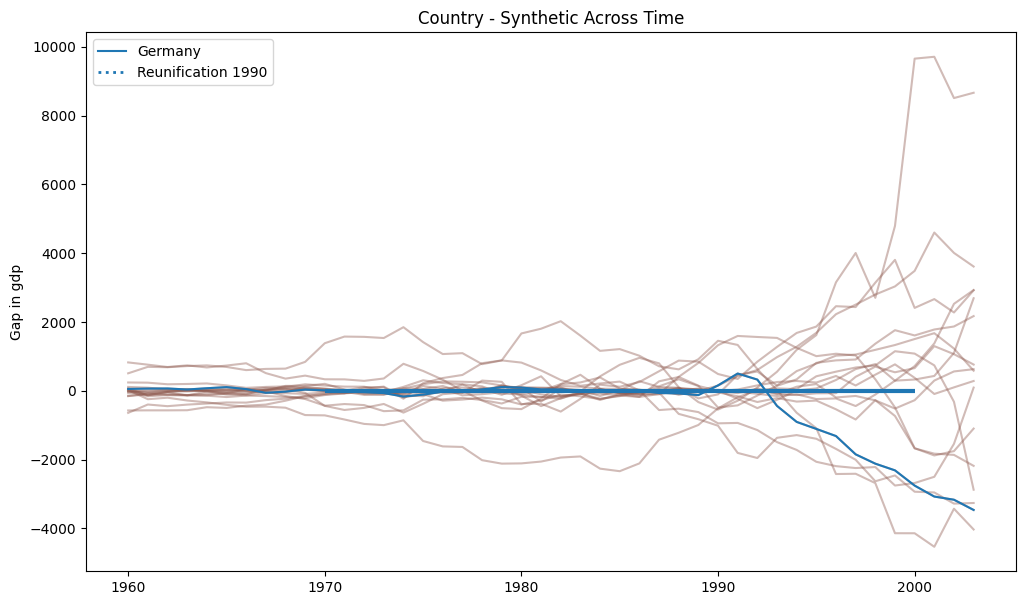

In [72]:
plt.figure(figsize=(12,7))
for state in synthetic_states:
    plt.plot(state["year"], state["gdp"] - state["synthetic"], color="C5",alpha=0.4)

plt.plot(data.query("west_germany")["year"], data.query("west_germany")["gdp"] - west_germany_synth,
        label="Germany");

plt.vlines(x=1990, ymin=-50, ymax=120, linestyle=":", lw=2, label="Reunification 1990")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=3)
plt.ylabel("Gap in gdp")
plt.title("Country - Synthetic Across Time")
plt.legend();

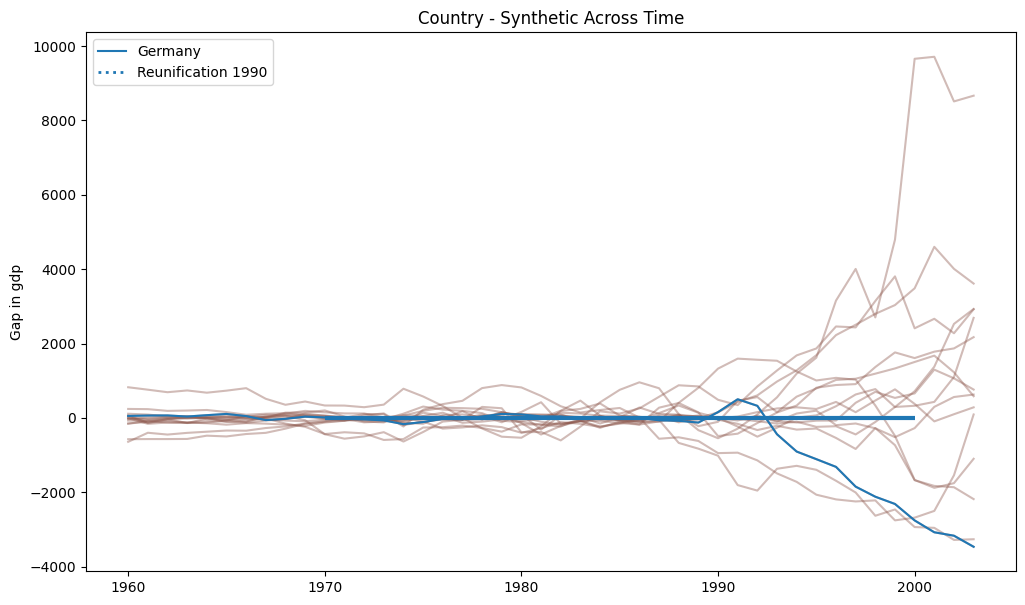

In [73]:
#After removing noise

def pre_treatment_error(state):
    pre_treat_error = (state.query("~after_treatment")["gdp"]
                       - state.query("~after_treatment")["synthetic"]) ** 2
    return pre_treat_error.mean()

plt.figure(figsize=(12,7))
for state in synthetic_states:

    if pre_treatment_error(state) < 700000:
        plt.plot(state["year"], state["gdp"] - state["synthetic"], color="C5",alpha=0.4)

plt.plot(data.query("west_germany")["year"], data.query("west_germany")["gdp"] - west_germany_synth,
        label="Germany");

plt.vlines(x=1990, ymin=-50, ymax=120, linestyle=":", lw=2, label="Reunification 1990")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=3)
plt.ylabel("Gap in gdp")
plt.title("Country - Synthetic Across Time")
plt.legend();

In [74]:
calif_number = 3

effects = [state.query("year==2000").iloc[0]["gdp"] - state.query("year==2000").iloc[0]["synthetic"]
           for state in synthetic_states
           if pre_treatment_error(state) < 700000] # filter out noise

wg_effect = data.query("west_germany & year==2000").iloc[0]["gdp"] - west_germany_synth[-1]

print("West Germany Treatment Effect for the Year 2000:", wg_effect)
np.array(effects)

West Germany Treatment Effect for the Year 2000: -5377.160389796387


array([ 2409.76219509,   717.48180988,   376.41050655,  -274.12453348,
        1504.03186344,   659.31899263, -2756.75516321, -1674.41076209,
        3485.46909899,  9657.00177641, -1669.67280408, -2681.80431351,
         326.74012732,  1608.89484321, -2934.63257023])

In [75]:
np.mean(np.array(effects) < wg_effect)

np.float64(0.0)

#### Important limitation of the reported tail fraction

The saved output labels **−5,377.16** as the “Year 2000” effect. But the code subtracts `west_germany_synth[-1]`, the **2003** synthetic value, from West Germany's observed **2000** GDP. Placebo gaps are evaluated in 2000. The resulting comparison does not use a common year.

Accordingly, the saved fraction **0.0** is **not a valid year-2000 permutation p-value** and cannot establish that the gap is “not by chance.” It is also an unadjusted strict-tail fraction, not a calibrated finite-sample test. The code and its output are preserved; this note corrects only their interpretation.

### 5. Earlier-cutoff diagnostic

The final exercise refits West Germany's synthetic comparison using observations through **1975**, with `placebo_at = year > 1975`. The purpose is to inspect how a synthetic trajectory trained on an earlier window behaves before the real event.

A clean pre-event falsification check should focus on years before actual reunification. The code below also evaluates a tail fraction in **2000**, after the real intervention; this cannot isolate an entirely pre-treatment placebo effect.

In [76]:
data['placebo_at'] = (data['year'] > 1975)

#### Earlier fit and country comparisons

The following saved plots display the refitted path and country-placebo gaps. The original legend calls the 1975 marker “Reunification”; it should be read as a **hypothetical cutoff**, not a historical event date. No plot labels have been changed.

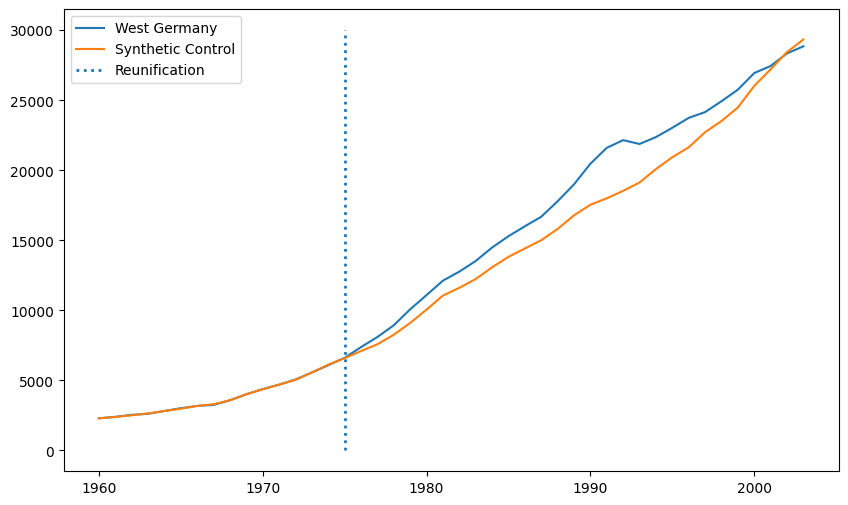

In [77]:
from joblib import Parallel, delayed

def synthetic_control(index: float, data: pd.DataFrame) -> np.array:

    features = ["gdp"]

    inverted = (data.query("~placebo_at")
                .pivot(index='index', columns="year")[features]
                .T)

    y = inverted[index].values # treated
    X = inverted.drop(columns=index).values # donor pool

    weights = get_w(X, y)
    synthetic = (data.query(f"~(index=={index})")
                 .pivot(index='year', columns="index")["gdp"]
                 .values.dot(weights))

    return (data
            .query(f"index=={index}")[["index", "year", "gdp", "placebo_at"]]
            .assign(synthetic=synthetic))



new_df = synthetic_control(7, data=data)



plt.figure(figsize=(10,6))
plt.plot(new_df["year"], new_df["gdp"], label="West Germany")
plt.plot(new_df["year"], new_df["synthetic"], label="Synthetic Control")
plt.vlines(x=1975, ymin=1, ymax=30000, linestyle=":", lw=2, label="Reunification")
plt.legend();

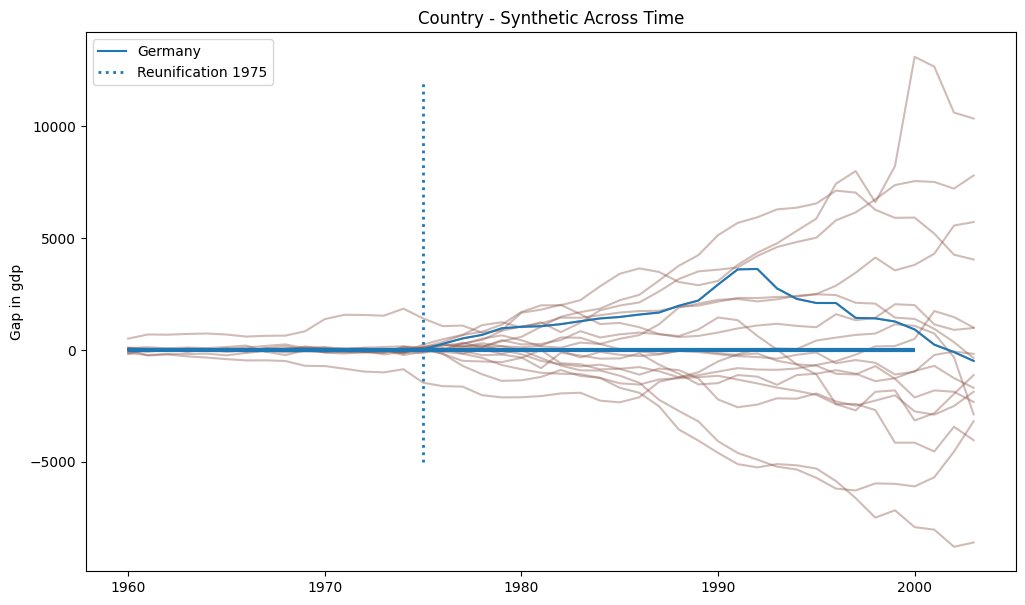

In [78]:
control_pool = data["index"].unique()

parallel_fn = delayed(partial(synthetic_control, data=data))

synthetic_states = Parallel(n_jobs=8)(parallel_fn(index) for index in control_pool)

plt.figure(figsize=(12,7))
for state in synthetic_states:
    plt.plot(state["year"], state["gdp"] - state["synthetic"], color="C5",alpha=0.4)

plt.plot(data.query("west_germany")["year"], data.query("west_germany")["gdp"] - new_df["synthetic"],
        label="Germany");

plt.vlines(x=1975, ymin=-5000, ymax=12000, linestyle=":", lw=2, label="Reunification 1975")
plt.hlines(y=0, xmin=1960, xmax=2000, lw=3)
plt.ylabel("Gap in gdp")
plt.title("Country - Synthetic Across Time")
plt.legend();

In [79]:
def pre_treatment_error(state):
    pre_treat_error = (state.query("~placebo_at")["gdp"]
                       - state.query("~placebo_at")["synthetic"]) ** 2
    return pre_treat_error.mean()


effects = [state.query("year==2000").iloc[0]["gdp"] - state.query("year==2000").iloc[0]["synthetic"]
           for state in synthetic_states
           if pre_treatment_error(state) < 700000] # filter out noise

wg_effect = data.query("west_germany & year==2000").iloc[0]["gdp"] - new_df.query("year==2000").iloc[0]["synthetic"]

print("West Germany Treatment Effect for the Year 2000:", wg_effect)
np.array(effects)

West Germany Treatment Effect for the Year 2000: 919.4467347983591


array([ 7552.72244647,  3807.87468426,  2006.91806281,  -970.53636384,
        -937.31994198, -2120.41961134,   919.4467348 ,  1389.10198769,
         499.38449586, 13109.57183381,  5919.90287993, -6095.90645096,
        1080.999249  , -3148.39394822, -2743.89989165, -7916.92661712])

In [80]:
np.mean(np.array(effects) < wg_effect) # pvalue > 0.05 therefore it's noise

np.float64(0.5)

### 6. Conclusions and scope

For the 1975-fit model, the saved year-2000 difference is about **919.45**, with a strict lower-tail fraction of **0.5**. This is descriptive and does not prove that the difference is noise or validate the main causal interpretation, particularly because the comparison year is after actual reunification.

The synthetic-control case demonstrates constrained optimization, donor-weight interpretation, trajectory comparison, and placebo construction. Its saved paths suggest a post-1990 GDP divergence, but the date mismatch in the main tail calculation, fitting through 1990, predictor missingness, and placebo design limit formal inference.

## Portfolio takeaways

- **Matching:** prediction accuracy is different from overlap and covariate balance; discarded observations change the target population.
- **Estimation:** variable matched-set sizes can make pair-average and pooled-regression contrasts differ.
- **Uncertainty:** reused controls and repeated source units complicate post-matching inference.
- **Synthetic control:** a plausible counterfactual requires more than close pre-period averages; donor selection, timing, and like-for-like placebo comparisons matter.

Future analytical changes could address these limitations, but **none is implemented in this presentation-only edition**. No entropy-balancing analysis or bootstrap is claimed.

## Sources and credits

- Gilligan, M. J., & Sergenti, E. (2008). *Do UN Interventions Cause Peace? Using Matching to Improve Causal Inference*. Quarterly Journal of Political Science. [Source cited in the original notebook](https://nowpublishers.com/article/Details/QJPS-7051).
- Matheus Facure, *Causal Inference for the Brave and True*, [Synthetic Control chapter](https://matheusfacure.github.io/python-causality-handbook/15-Synthetic-Control.html), acknowledged implementation reference.
- The original notebook discusses propensity-score theory and post-matching inference, citing Rosenbaum and Rubin (1983), Abadie and Imbens (2006), and Abadie and Spiess (2021). Those references are conceptual context, not a certification that the preserved implementation meets their assumptions.

Original collaborative analysis: **Jonathan Sauer, Muhammad Murodzoda, Sebastian Aguilar**. Portfolio presentation prepared for Muhammad Murodzoda. The supplied data and referenced research retain their original attribution.